In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
import seaborn as sns
from sklearn.calibration import calibration_curve

In [2]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df['encoded_igi_call'] = 1*(groundtruth_df.igi_call == 'Positive')
groundtruth_df['groundtruth_label'] = 1*(groundtruth_df.groundtruth == 1)


In [3]:
fusion_vit_test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')
fusion_vit_test_pred = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(fusion_vit_test_pred, how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
fusion_vit_test_pred = fusion_vit_test_pred.rename(columns={'prob':'outputs'})

In [4]:
fusion_vit_retest_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_retest_pred_df.csv')
retest_df = (fusion_vit_retest_pred
 .merge(join_df[['sample_id','curve_idx','target','igi_call','final_patient_result','current_sample_result']].drop_duplicates(),
        how = 'inner', on = 'curve_idx'))

retest_df['encoded_igi_call'] = 1*(retest_df.igi_call == 'Positive')
retest_df['groundtruth_label'] = 0
retest_df.loc[retest_df.target.isin(['RnaseP','MS2']), 'groundtruth_label'] = 1
retest_df.loc[(retest_df.target.isin(['RnaseP','MS2'])) & (retest_df.final_patient_result == 'Positive'), 'groundtruth_label'] = 1

In [5]:
known_df = pd.read_csv('../data/known_dilution_data.csv', index_col=0)
known_df.head()

,cycle_no,target,rn,drn,amp_status,amp_score,cq,auto_threshold,threshold,baseline_start,baseline_end,file,dilution_level,covid_variant,Fn,curve_idx
well_position,,,,,,,,,,,,,,,,
A1,1,RnaseP,15502.66309,1163.431414,No Amp,1.44458,Undetermined,False,20000,3,44,dilution,100000,Delta,15502.663,192_known
A1,2,RnaseP,15452.75391,957.857776,No Amp,1.44458,Undetermined,False,20000,3,44,dilution,100000,Delta,15452.754,192_known
A1,3,RnaseP,15458.61523,808.054645,No Amp,1.44458,Undetermined,False,20000,3,44,dilution,100000,Delta,15458.615,192_known
A1,4,RnaseP,15620.69824,814.473195,No Amp,1.44458,Undetermined,False,20000,3,44,dilution,100000,Delta,15620.698,192_known
A1,5,RnaseP,15775.45313,813.563619,No Amp,1.44458,Undetermined,False,20000,3,44,dilution,100000,Delta,15775.453,192_known


### 1) The current IGI threshold-based PCR-test evaluation system is imperfect 
a.Overall system has a low false positive rate


In [6]:
df = groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
fpr = (df[(df.encoded_igi_call == 1) & (df.groundtruth_label == 0)].shape[0]/
      df[(df.encoded_igi_call == 1)].shape[0]*100)
print(f'IGI false positive rate on control curves is {round(fpr,2)}%.')

IGI false positive rate on control curves is 0.03%.


b) But there are several false negative tests both at the curve and at the sample level 

In [7]:
control_fnr = (df[(df.encoded_igi_call == 0) & (df.groundtruth_label == 1)].shape[0]/
               df[df.encoded_igi_call == 0].shape[0])*100
print(f'IGI false negative rate on control curves is {round(control_fnr,2)}%.')


IGI false negative rate on control curves is 28.03%.


In [8]:
control_sample_df = (groundtruth_df[['sample_id','curve_idx','target','groundtruth_label','encoded_igi_call']].drop_duplicates()
                     .merge(join_df[['curve_idx','current_sample_result']].drop_duplicates(),
                            on = 'curve_idx', how='inner')
                    #  .fillna('Invalid')  
 .groupby(['sample_id','current_sample_result'])
 .agg(cnt = ('target', 'nunique'),
     igi_call = ('encoded_igi_call', 'mean'),
      groundtruth = ('groundtruth_label','mean'))
 .reset_index())
control_sample_df = control_sample_df[control_sample_df.cnt != 1]
control_sample_fnr = (control_sample_df[(control_sample_df.igi_call == 0) & (control_sample_df.groundtruth == 1)].shape[0]/control_sample_df[(control_sample_df.igi_call == 0)].shape[0])
print(f'IGI false negative rate on control samples is {round(control_sample_fnr*100,2)}%.')

IGI false negative rate on control samples is 0.0%.


In [9]:
inconclusive_control_sample_rate = 100*control_sample_df[control_sample_df.igi_call != control_sample_df.groundtruth].shape[0]/control_sample_df.shape[0]
print(f'IGI control sample inconclusive rate is {round(inconclusive_control_sample_rate,2)}%.')

IGI control sample inconclusive rate is 7.81%.


In [10]:
clinical_sample_df = (join_df
 .loc[(join_df.sample_type == 'Clinical Sample'), ['sample_id','current_sample_result','final_patient_result','retest_sample_id_1','retest_sample_id_2']]
 .drop_duplicates())
retest_rate = clinical_sample_df[(clinical_sample_df.retest_sample_id_1 != ' ')].shape[0]/clinical_sample_df.shape[0]
print(f'IGI retest rate is {round(retest_rate,2)}%.')

IGI retest rate is 0.06%.


In [11]:
retest_twice_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df.shape[0]
retest_retest_rate = clinical_sample_df.loc[clinical_sample_df.retest_sample_id_2 != ' '].shape[0]/clinical_sample_df[clinical_sample_df.retest_sample_id_1 != ' '].shape[0]
print(f'IGI retest rate twice is {round(retest_twice_rate, 2)}%.')
print(f'IGI retest retest rate twice is {round(retest_retest_rate,2)}%.')

IGI retest rate twice is 0.01%.
IGI retest retest rate twice is 0.11%.


c) This performance problems may be driven by the simple threshold-based classification rule implemented by the IGI, which neglects further information provided by the complete amplification trajectory

In [12]:
pd.set_option('display.max_rows', None)
(groundtruth_df
#  .loc[groundtruth_df.encoded_igi_call != groundtruth_df.groundtruth_label,
 .loc[(groundtruth_df.encoded_igi_call == 0) & (groundtruth_df.groundtruth_label == 1),
      ['curve_idx','encoded_igi_call','groundtruth_label']].drop_duplicates()
 .merge(join_df[['curve_idx','sample_type','target','well_position','amp_score','record_type','file']].drop_duplicates(), 
        how='inner', on='curve_idx')
 .merge(fusion_vit_test_pred[['curve_idx','outputs']], how='inner', on='curve_idx')
 .sort_values(['outputs','amp_score']))

,curve_idx,encoded_igi_call,groundtruth_label,sample_type,target,well_position,amp_score,record_type,file,outputs
1,52562,0,1,Positive Control (qPCR),E gene,N19,1.720351,Control Sample,gxwf,0.001941
0,52538,0,1,Positive Control (qPCR),E gene,M19,0.000000,Control Sample,gxwf,0.002849
2,52564,0,1,Positive Control (qPCR),E gene,N20,0.000000,Control Sample,gxwf,0.004409
232,6608,0,1,Clinical Sample,MS2,E1,0.000000,Submitted Sample,darv,0.047360
196,31798,0,1,Clinical Sample,MS2,I13,0.000000,Submitted Sample,dbjb,0.068387
243,7389,0,1,Clinical Sample,MS2,C7,1.429761,Submitted Sample,darx,0.079091
238,119843,0,1,Clinical Sample,RnaseP,A5,0.000000,Submitted Sample,h0yg,0.116568
224,108558,0,1,Clinical Sample,RnaseP,K22,1.234355,Re-Test Sample,h0vk,0.141297
197,31859,0,1,Clinical Sample,MS2,M3,1.512374,Pooled Sample,dbjb,0.156488
24,107368,0,1,Clinical Sample,RnaseP,J1,0.000000,Pooled Sample,h0v8,0.162188


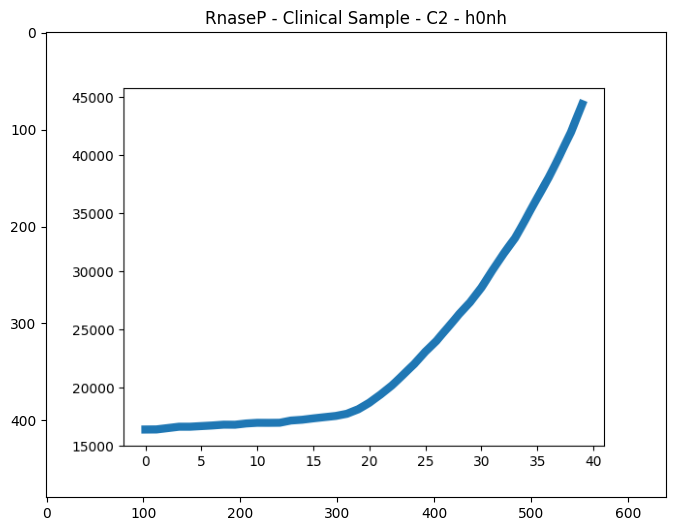

In [13]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

fig = plt.figure(frameon=False)
fig.set_size_inches(8,10)

img = mpimg.imread('../data/curve_imgs_axis/curve_81867.png')
ax = plt.Axes(fig, [0., 0., 1., 1.])
ax.set_axis_off()
# fig.add_axes(ax)
# ax.bar_label(ax.containers[0])
# plt.title('Contribution')

plt.title('RnaseP - Clinical Sample - C2 - h0nh')
plt.imshow(img)
plt.show()

### 2) We have developed a machine learning model that surpasses the accuracy of the IGI on a test set of control samples
#### a) AUC


In [69]:
test_igi_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call)

igi_tn, igi_fp, igi_fn, igi_tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.encoded_igi_call).ravel()

igi_precision = igi_tp/(igi_fp + igi_tp)
igi_sensitivity = igi_tp/(igi_tp + igi_fn)
igi_specificity = igi_tn/(igi_tn + igi_fp)
igi_f1 = 2*igi_tp/(2*igi_tp + igi_fp + igi_fn)
igi_acc = (igi_tp+igi_tn)/(igi_tp+igi_tn+igi_fp+igi_fn)
igi_fnr = igi_fn/(igi_fn + igi_tn)
igi_fpr = igi_fp/(igi_fp+igi_tp)
igi_tpr = (igi_tp)/(igi_tp + igi_fp)

# print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
# print('IGI negative predictions:', igi_neg_pred)
# print('IGI precision score:', igi_precision)
# print('IGI sensitivity score:', igi_sensitivity)
# print('IGI specificity:', igi_specificity)
# print('IGI F1:', igi_f1)
# print('IGI accuracy:', igi_acc)

print('IGI AUC:', test_igi_auc)
print(f'IGI accuracy: {igi_acc}')
print(f'IGI precision: {igi_precision}')
print(f'IGI sensitivity: {igi_sensitivity}')
print(f'IGI F1 score: {igi_f1}')
print(f'IGI TP = {igi_tp}; TN = {igi_tn}; FP = {igi_fp}; FN = {igi_fn}')
print(f'IGI FNR = {igi_fnr} and FPR = {igi_fpr}')

IGI AUC: 0.9773955331412103
IGI accuracy: 0.9593522267206478
IGI precision: 1.0
IGI sensitivity: 0.9547910662824207
IGI F1 score: 0.9768727540772136
IGI TP = 5301; TN = 623; FP = 0; FN = 251
IGI FNR = 0.28718535469107553 and FPR = 0.0


In [70]:
retest_igi_tn, retest_igi_fp, retest_igi_fn, retest_igi_tp = confusion_matrix(retest_df.groundtruth_label, retest_df.encoded_igi_call).ravel()

retest_igi_precision = retest_igi_tp/(retest_igi_fp + retest_igi_tp)
retest_igi_sensitivity = retest_igi_tp/(retest_igi_tp + retest_igi_fn)
retest_igi_specificity = retest_igi_tn/(retest_igi_tn + retest_igi_fp)
retest_igi_f1 = 2*retest_igi_tp/(2*retest_igi_tp + retest_igi_fp + retest_igi_fn)
retest_igi_acc = (retest_igi_tp+retest_igi_tn)/(retest_igi_tp+retest_igi_tn+retest_igi_fp+retest_igi_fn)
retest_igi_fnr = retest_igi_fn/(retest_igi_fn + retest_igi_tn)
retest_igi_fpr = retest_igi_fp/(retest_igi_fp+retest_igi_tp)
retest_igi_tpr = (retest_igi_tp)/(retest_igi_tp + retest_igi_fp)

# print('IGI AUC:', test_igi_auc)
print('On curve level')
print(f'IGI retest accuracy: {retest_igi_acc}')
print(f'IGI retest precision: {igi_precision}')
print(f'IGI retest sensitivity: {igi_sensitivity}')
print(f'IGI retest F1 score: {retest_igi_f1}')
print(f'IGI retest TP = {retest_igi_tp}; TN = {retest_igi_tn}; FP = {retest_igi_fp}; FN = {retest_igi_fn}')
print(f'IGI retest FNR = {igi_fnr} and FPR = {retest_igi_fpr}')

On curve level
IGI retest accuracy: 0.7661606268364348
IGI retest precision: 1.0
IGI retest sensitivity: 0.9547910662824207
IGI retest F1 score: 0.6356352537199542
IGI retest TP = 833; TN = 2296; FP = 552; FN = 403
IGI retest FNR = 0.28718535469107553 and FPR = 0.39855595667870036


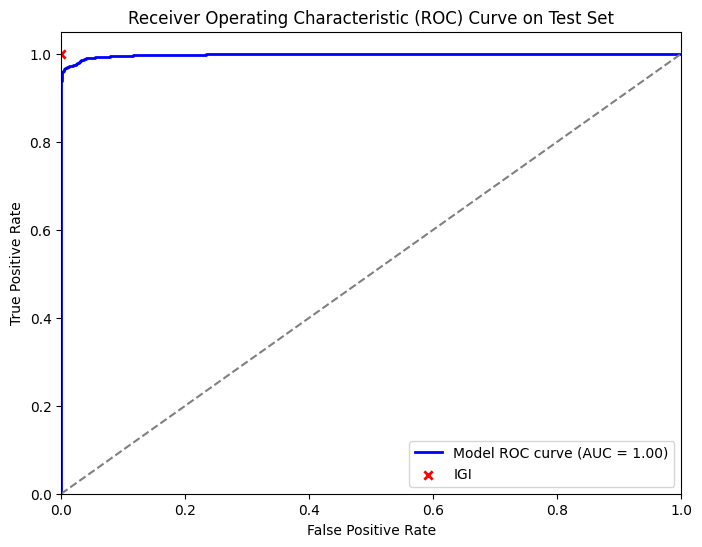

In [71]:

test_auc = roc_auc_score(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(igi_fpr, igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


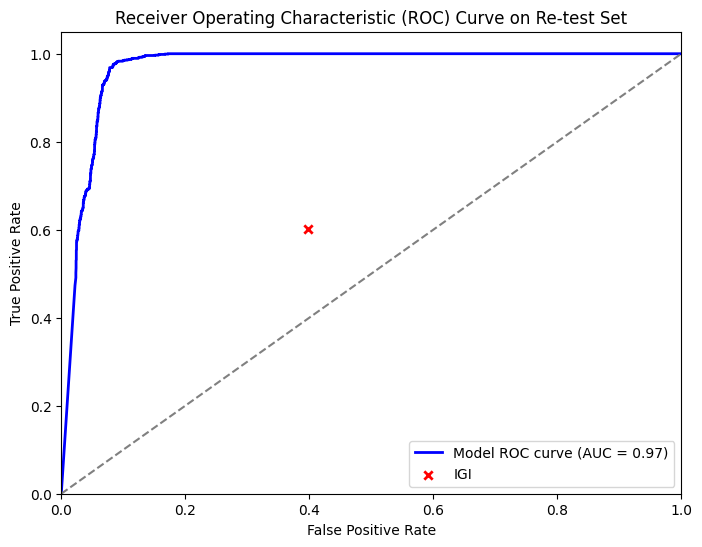

In [73]:
retest_auc = roc_auc_score(retest_df.groundtruth_label, retest_df.outputs)
retest_fpr, retest_tpr, retest_thresholds = roc_curve(retest_df.groundtruth_label, retest_df.outputs)

plt.figure(figsize=(8, 6))
plt.plot(retest_fpr, retest_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(retest_auc))
# plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.scatter(retest_igi_fpr, retest_igi_tpr, color = 'red', marker = 'x', linewidths=2, label='IGI')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Set')
plt.legend(loc='lower right')
plt.show()


In [74]:
## test set
thresholds = np.linspace(0.1, 1, 1000)
tns, tps, fns, fps = [], [], [], []
for thres in thresholds:
    pred = 1*(fusion_vit_test_pred.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(fusion_vit_test_pred.groundtruth_label, pred).ravel()
    tns.append(tn)
    tps.append(tp)
    fns.append(fn)
    fps.append(fp)

tns, tps, fns, fps = np.array(tns), np.array(tps), np.array(fns), np.array(fps)

accuracy = (tps+tns)/(tps+tns+fps+fns)
precision = (tps)/(tps + fps)
sensitivity = (tps)/(tps + fns)
neg_preds = fns + tns
f1_scores = 2*tps/(2*tps + fps + fns)
fpr = fps/(fps + tps)
fnr = fns/(fns + tns)

## retest set
retest_tns, retest_tps, retest_fns, retest_fps = [], [], [], []
for thres in thresholds:
    pred = 1*(retest_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(retest_df.groundtruth_label, pred).ravel()
    retest_tns.append(tn)
    retest_tps.append(tp)
    retest_fns.append(fn)
    retest_fps.append(fp)

retest_tns, retest_tps, retest_fns, retest_fps = np.array(retest_tns), np.array(retest_tps), np.array(retest_fns), np.array(retest_fps)

retest_accuracy = (retest_tps+retest_tns)/(retest_tps+retest_tns+retest_fps+retest_fns)
retest_precision = (retest_tps)/(retest_tps + retest_fps)
retest_sensitivity = (retest_tps)/(retest_tps + retest_fns)
retest_neg_preds = retest_fns + retest_tns
retest_f1_scores = 2*retest_tps/(2*retest_tps + retest_fps + retest_fns)
retest_fpr = retest_fps/(retest_fps + retest_tps)
retest_fnr = retest_fns/(retest_fns + retest_tns)



a) Picking threshold based on criteria
* Best accuracy

In [75]:
idx = accuracy.argmax()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With TP = 5507; TN = 589; FP = 34; FN = 45
With FNR = 0.07097791798107256 and FPR = 0.006136076520483667


In [76]:
print('On retest dataset')
print(f'With accuracy: {retest_accuracy[idx]}')
print(f'With precision: {retest_precision[idx]}')
print(f'With sensitivity: {retest_sensitivity[idx]}')
print(f'With F1 score: {retest_f1_scores[idx]}')
print(f'With TP = {retest_tps[idx]}; TN = {retest_tns[idx]}; FP = {retest_fps[idx]}; FN = {retest_fns[idx]}')
print(f'With FNR = {retest_fnr[idx]} and FPR = {retest_fpr[idx]}')

On retest dataset
With accuracy: 0.9324191968658179
With precision: 0.8448275862068966
With sensitivity: 0.9514563106796117
With F1 score: 0.8949771689497716
With TP = 1176; TN = 2632; FP = 216; FN = 60
With FNR = 0.022288261515601784 and FPR = 0.15517241379310345


Text(0.5, 1.0, 'Best Accuracy Threshold on Retest')

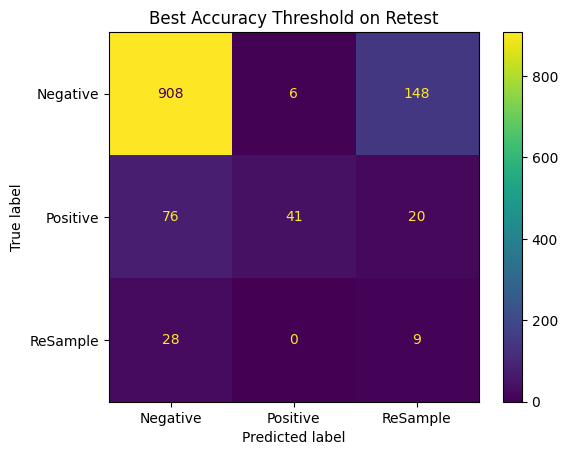

In [77]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy Threshold on Retest')

Text(0.5, 1.0, 'IGI on Retest')

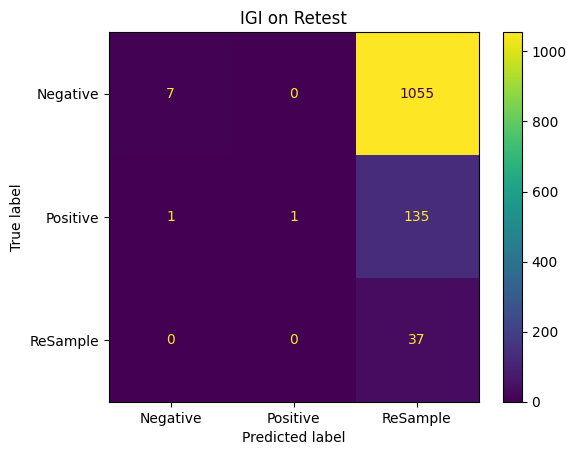

In [78]:
cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.current_sample_result_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('IGI on Retest')

* Best sensitivity

Since there is multplie thresholds that give the same maximum sensitivity, we pick the threshold that also has maximum precision and accuracy, lowest false negative rate and false positive rate among the group. 

In [79]:
ids = np.where(sensitivity == sensitivity.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [80]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.11621621621621622
With accuracy: 0.9685829959514171
With precision: 0.9675392670157068
With sensitivity: 0.9985590778097982
With F1 score: 0.9828044672930332
With TP = 5544; TN = 437; FP = 186; FN = 8
With FNR = 0.017977528089887642 and FPR = 0.032460732984293195


Text(0.5, 1.0, 'Best Sensitivity Threshold on Retest')

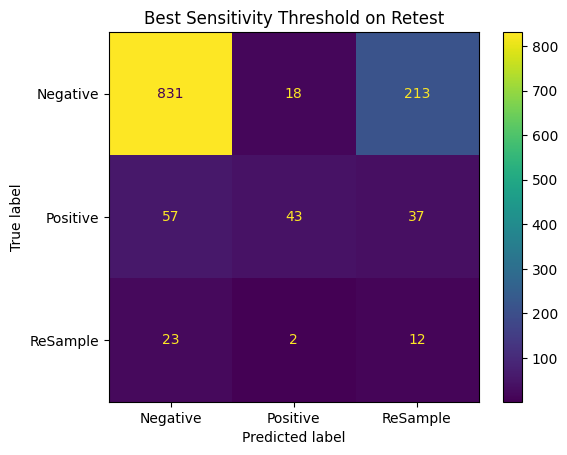

In [81]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity Threshold on Retest')

* Best precision

Since there is multplie thresholds that give the same maximum precision, we pick the threshold that also has maximum sensitivity and accuracy, lowest false negative rate and false positive rate among the group. 

In [82]:
ids = np.where(precision == precision.max())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_scores': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [83]:
idx = df.sort_values('sensitivity', ascending=False).reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


Text(0.5, 1.0, 'Best Precision Threshold on Retest')

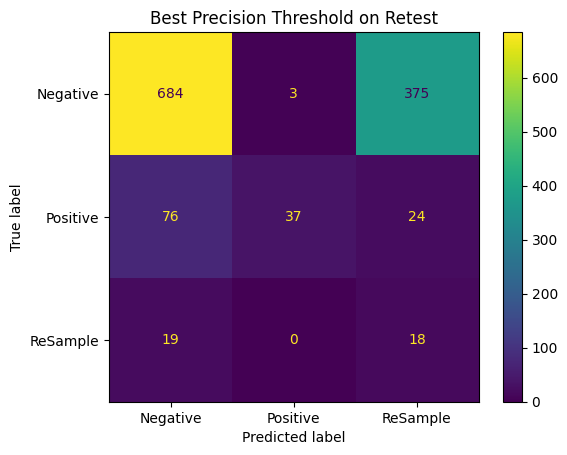

In [84]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision Threshold on Retest')

* Best f1 score

In [113]:
idx = f1_scores.argmax()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.5657657657657658
With accuracy: 0.9872064777327936
With precision: 0.9938639234795164
With sensitivity: 0.9918948126801153
With F1 score: 0.9928783917785992
With TP = 5507; TN = 589; FP = 34; FN = 45
With FNR = 0.07097791798107256 and FPR = 0.006136076520483667


Text(0.5, 1.0, 'Best Accuracy / F1 Score Threshold on Retest')

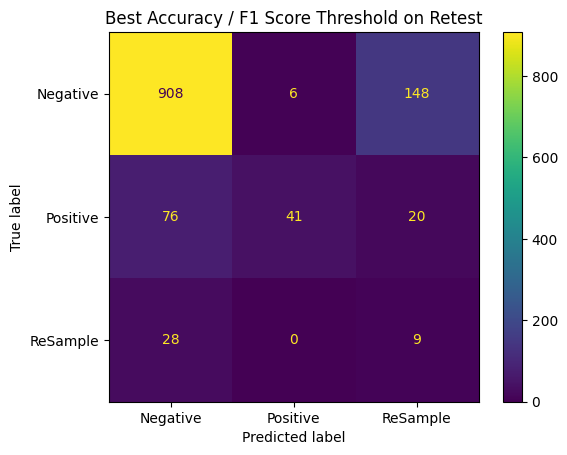

In [114]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Accuracy / F1 Score Threshold on Retest')

* Best false negative rate

In [115]:
idx = fnr.argmin()
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.11621621621621622
With accuracy: 0.9685829959514171
With precision: 0.9675392670157068
With sensitivity: 0.9985590778097982
With F1 score: 0.9828044672930332
With TP = 5544; TN = 437; FP = 186; FN = 8
With FNR = 0.017977528089887642 and FPR = 0.032460732984293195


Text(0.5, 1.0, 'Best Sensitivity / False Negative Rate Threshold on Retest')

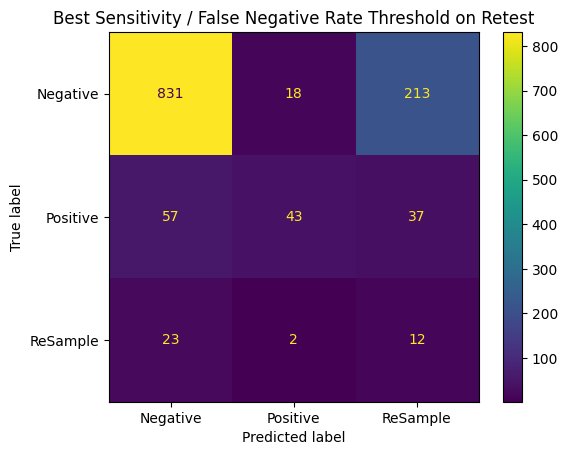

In [116]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Sensitivity / False Negative Rate Threshold on Retest')

* Best false positive rate

In [117]:
ids = np.where(fpr == fpr.min())

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])


In [118]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


Text(0.5, 1.0, 'Best Precision / False Positive Rate Threshold on Retest')

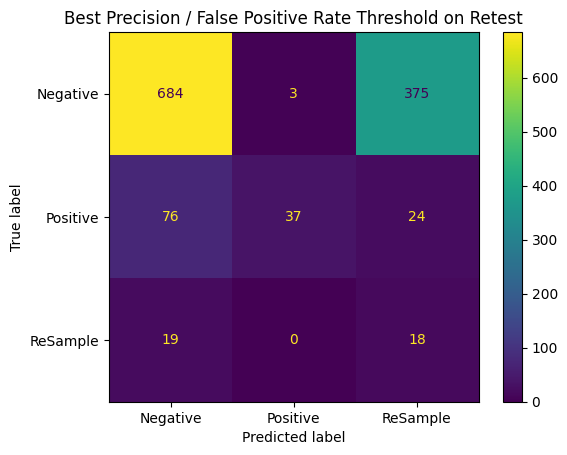

In [120]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision / False Positive Rate Threshold on Retest')

b) Picking threshold based on matching metrics with igi_acc
* False Positive Rate

In [121]:
ids = np.where(fpr == igi_fpr)

df = pd.DataFrame()
for idx in list(ids):    
    df = pd.concat([df, pd.DataFrame({'idx': idx, 
                                      'thres': thresholds[idx],
                   'acc': accuracy[idx],
                   'precision': precision[idx],
                   'sensitivity': sensitivity[idx],
                   'f1_score': f1_scores[idx],
                   'tp': tps[idx],
                   'tn': tns[idx],
                   'fn': fns[idx],
                   'fp': fps[idx],
                   'fnr': fnr[idx],
                   'fpr': fpr[idx]})])

In [122]:
idx = df.sort_values('fnr').reset_index().loc[0,'idx']
print(f'IGI fpr: {igi_fpr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fpr: 0.0
Model AUC: 0.997836882057165
We use threshold at: 0.9963963963963964
With accuracy: 0.9433198380566802
With precision: 1.0
With sensitivity: 0.9369596541786743
With F1 score: 0.9674539706155849
With TP = 5202; TN = 623; FP = 0; FN = 350
With FNR = 0.3597122302158273 and FPR = 0.0


Text(0.5, 1.0, 'Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

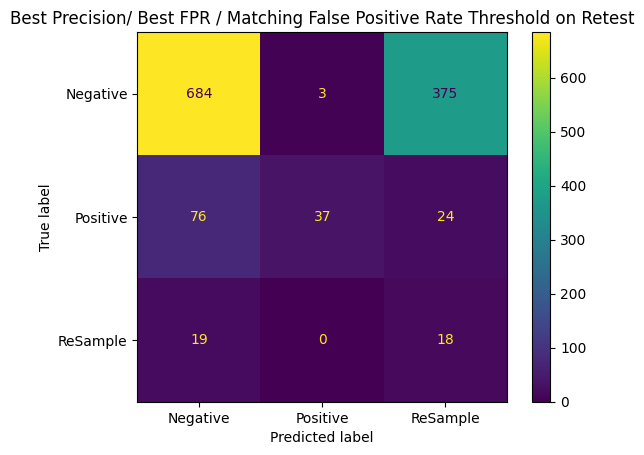

In [123]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Best Precision/ Best FPR / Matching False Positive Rate Threshold on Retest')

* False negative rate

In [104]:
idx = np.where(np.round(fnr,3) == round(igi_fnr,3))[0][0]
print(f'IGI fnr: {igi_fnr}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI fnr: 0.28718535469107553
Model AUC: 0.997836882057165
We use threshold at: 0.9783783783783784
With accuracy: 0.9593522267206478
With precision: 0.9998114274938714
With sensitivity: 0.954971181556196
With F1 score: 0.9768770152003685
With TP = 5302; TN = 622; FP = 1; FN = 250
With FNR = 0.286697247706422 and FPR = 0.00018857250612860644


Text(0.5, 1.0, 'Matching False Negative Rate Threshold on Retest')

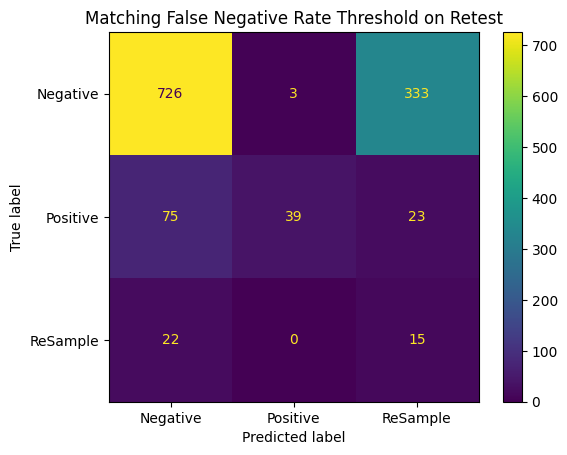

In [105]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching False Negative Rate Threshold on Retest')

* Positive predictions

In [106]:
idx = np.where((tps + fps) == (igi_tp + igi_fp))[0][0]
print(f'IGI number of positive prediction: {igi_tp + igi_fp}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of positive prediction: 5301
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.28832951945080093 and FPR = 0.00018864365214110544


Text(0.5, 1.0, 'Matching Positive Prediction Threshold on Retest')

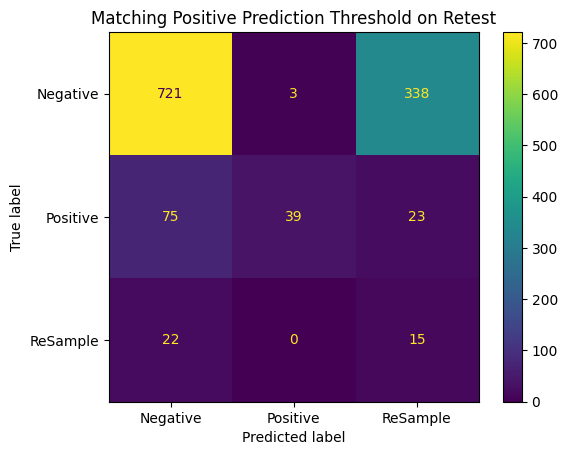

In [107]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive Prediction Threshold on Retest')

* Negative Predictions

In [124]:
idx = np.where((fns + tns) == (igi_fn + igi_tn))[0][0]
print(f'IGI number of negative prediction: {igi_tn + igi_fn}')
print(f'Model AUC: {test_auc}')
print(f'We use threshold at: {thresholds[idx]}')
print(f'With accuracy: {accuracy[idx]}')
print(f'With precision: {precision[idx]}')
print(f'With sensitivity: {sensitivity[idx]}')
print(f'With F1 score: {f1_scores[idx]}')
print(f'With TP = {tps[idx]}; TN = {tns[idx]}; FP = {fps[idx]}; FN = {fns[idx]}')
print(f'With FNR = {fnr[idx]} and FPR = {fpr[idx]}')

IGI number of negative prediction: 874
Model AUC: 0.997836882057165
We use threshold at: 0.9792792792792793
With accuracy: 0.9590283400809717
With precision: 0.9998113563478589
With sensitivity: 0.9546109510086456
With F1 score: 0.9766884732332074
With TP = 5300; TN = 622; FP = 1; FN = 252
With FNR = 0.28832951945080093 and FPR = 0.00018864365214110544


Text(0.5, 1.0, 'Matching Positive / Negative Prediction Threshold on Retest')

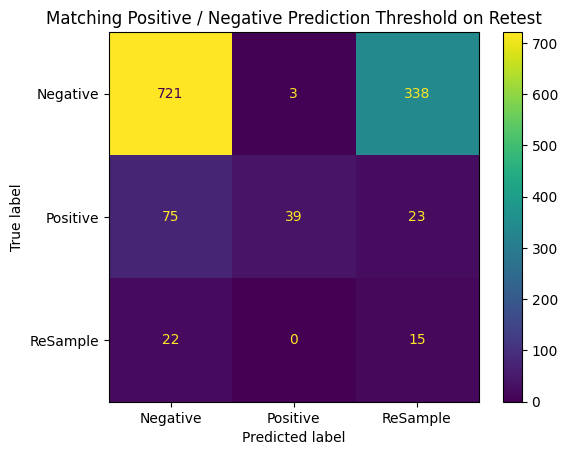

In [125]:
retest_sample_df = retest_df.copy()
retest_sample_df['pred'] = 1*(retest_sample_df.outputs >= thresholds[idx])

invalid_sample_id = retest_sample_df[(retest_sample_df.target.isin(['MS2','RnaseP'])) & (retest_sample_df.pred == 0)].sample_id

retest_sample_df = (retest_sample_df
                    .loc[~retest_sample_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .agg(sample_prob = ('pred', 'mean'))
 .reset_index())
retest_sample_df['sample_pred'] = None
retest_sample_df.loc[retest_sample_df.sample_prob > 0.5, 'sample_pred'] = 'Positive'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (~retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Negative'
retest_sample_df.loc[(retest_sample_df.sample_prob == 0) & (retest_sample_df.sample_id.isin(invalid_sample_id)), 'sample_pred'] = 'Invalid'
retest_sample_df.loc[(retest_sample_df.sample_prob > 0) & (retest_sample_df.sample_prob <= 0.5), 'sample_pred'] = 'Inconclusive'
retest_sample_df['sample_pred_3'] = retest_sample_df.sample_pred.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})
retest_sample_df['current_sample_result_3'] = retest_sample_df.current_sample_result.replace({'Inconclusive': 'ReSample',
                                                                          'Invalid': 'ReSample'})

cm = confusion_matrix(retest_sample_df.final_patient_result, retest_sample_df.sample_pred_3, labels = ['Negative','Positive','ReSample'])
ConfusionMatrixDisplay(cm, display_labels= ['Negative','Positive','ReSample']).plot()
plt.title('Matching Positive / Negative Prediction Threshold on Retest')

### Extra Plots

[]

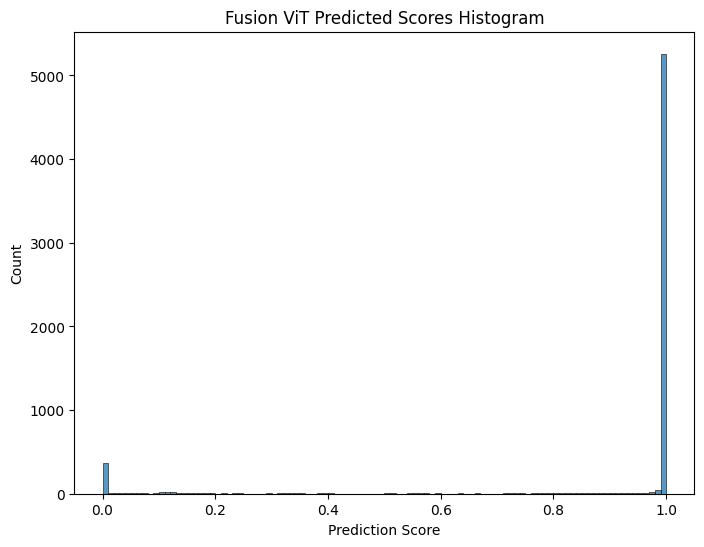

In [41]:
plt.figure(figsize=(8, 6))
sns.histplot(fusion_vit_test_pred, x = 'outputs', binwidth=0.01)
plt.title('Fusion ViT Predicted Scores Histogram')
plt.xlabel('Prediction Score')
plt.plot()

Text(0.5, 0, 'False Positive Rate')

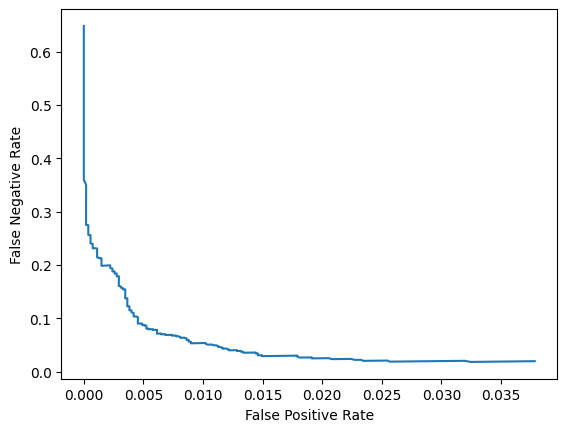

In [44]:
plt.plot(fpr, fnr)
plt.ylabel('False Negative Rate')
plt.xlabel('False Positive Rate')

[]

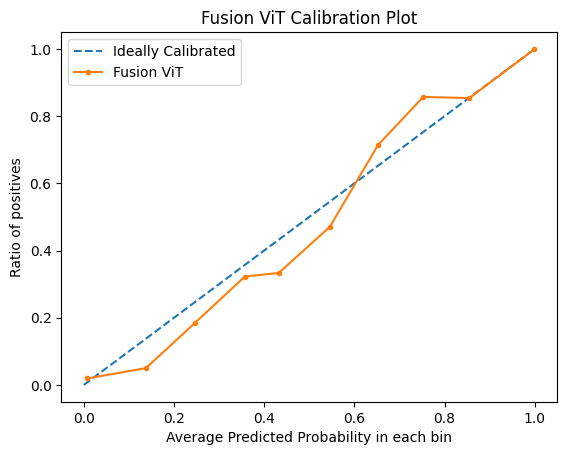

In [49]:
x,y = calibration_curve(fusion_vit_test_pred.groundtruth_label, fusion_vit_test_pred.outputs, n_bins=10)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')
plt.plot(y,x, marker = '.', label = 'Fusion ViT')
plt.title('Fusion ViT Calibration Plot')
leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.plot()